In [13]:

import os
import matplotlib.pyplot as plt
import torch
import numpy as np


import pyro
import pyro.contrib.gp as gp
import pyro.distributions as dist

from matplotlib.animation import FuncAnimation
from mpl_toolkits.axes_grid1 import make_axes_locatable

import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from pathlib import Path
import sys

# Add the project root to the Python path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.local_stats import GibbsKernel
import matplotlib.pyplot as plt
import pandas as pd

from src.models.parameters import get_all_parameter_interpolants

from typing import Callable

In [14]:
assert pyro.__version__.startswith('1.9.1')
pyro.set_rng_seed(0)
torch.set_default_dtype(torch.float64)

In [15]:
params_df = pd.read_csv(os.path.join(project_root, "data", "processed", "MLP001_params.csv"))
ocv_df = pd.read_csv(os.path.join(project_root, "data", "processed", "MLP001_ocv.csv"))

interpolants = get_all_parameter_interpolants(params_df, ocv_df, method="clough_tocher")

# X will be just the r0 values, and for now just soc.
# for this, we will also just use the values at 25 deg

x_df = params_df[params_df["Temperature_degC"] == 25]["SOC"].dropna()
y_df = params_df[params_df["Temperature_degC"] == 25]["R0 [Ohm]"].dropna()

# drop the first and last values of x_df and y_df, because they are outliers and will mess up the GP regression. This is because the GP regression is very sensitive to outliers, and we want to test the kernels on the "normal" data.
# x_df = x_df.iloc[1:-1]
# y_df = y_df.iloc[1:-1]

X = torch.tensor(x_df.to_numpy(), dtype=torch.float32)
Y = torch.tensor(y_df.to_numpy(), dtype=torch.float32)

train_X.dtype=torch.float64, train_Y.dtype=torch.float64, test_soc.dtype=torch.float64
tensor(6.7763e-21, grad_fn=<MaxBackward1>)


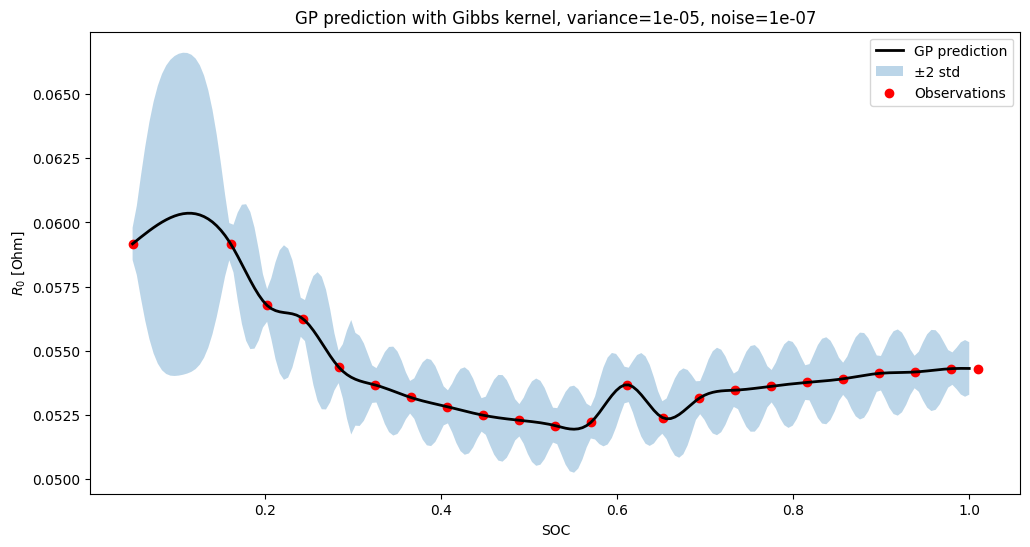

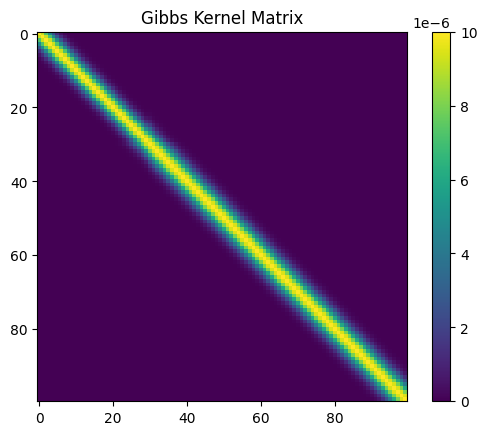

In [19]:
interp_r0 = lambda x: torch.tensor(interpolants["R0 [Ohm]"](x.numpy(), 25.0), dtype=torch.float64)
test_soc = torch.linspace(0.05, 1, 200).reshape(-1, 1)
from pyro.contrib.gp.models import GPRegression
pyro.clear_param_store()

train_X = X.reshape(-1, 1)
train_Y = torch.zeros_like(train_X).reshape(-1)  # Assuming zero mean for the GP prior
# make them all float64 for consistency with the GPRegression model
train_X = train_X.double()
train_Y = train_Y.double()
test_soc = test_soc.double()


def lengthscale_func(soc):
    return 0.025 + 0.005* torch.sigmoid(5000 * (soc - 0.3))

variance = 1e-5
noise = 1e-7

kernel = GibbsKernel(input_dim=1, lengthscale_fn=lengthscale_func, variance=torch.tensor(variance, dtype=torch.float64))

K_xx = kernel(train_X, train_X)
K_xs = kernel(train_X, test_soc)
K_ss = kernel(test_soc, test_soc)

L = torch.linalg.solve(K_xx + noise * torch.eye(len(train_X)), K_xs)

posterior_cov = K_ss - K_xs.T @ L
alpha = torch.linalg.solve(K_xx + noise * torch.eye(len(train_X)), train_Y)

posterior_mean = K_xs.T @ alpha


# check dtypes of train_X, train_Y, test_soc
print(f"{train_X.dtype=}, {train_Y.dtype=}, {test_soc.dtype=}")


mean,cov = posterior_mean, posterior_cov

std = torch.sqrt(torch.diag(cov))

soc = test_soc.squeeze()

ys = interp_r0(test_soc).squeeze(-1) + mean.detach().squeeze()

K = kernel(train_X)
Kinv = torch.linalg.inv(K)

posterior = K - K @ Kinv @ K

print(torch.max(torch.abs(posterior)))


plt.figure(figsize=(12,6))
plt.plot(
    soc,
    ys,
    'k',
    linewidth=2,
    label="GP prediction"
)
plt.fill_between(
    soc,
    (ys - 2*std).detach(),
    (ys + 2*std).detach(),
    alpha=0.3,
    label="±2 std"
)

plt.scatter(
    X.squeeze(),
    Y.squeeze(),
    color="red",
    label="Observations"
)

plt.legend()
plt.xlabel("SOC")
plt.ylabel(r"$R_0$ [Ohm]")
plt.title(f"GP prediction with Gibbs kernel, variance={variance}, noise={noise}")
#plt.savefig("gp_prediction_gibbs_kernel.pdf", bbox_inches='tight')
plt.show()
plt.cla()
x1 = torch.linspace(0, 1, 100).reshape(-1,1)

K = kernel(x1, x1)

plt.imshow(K.detach())
plt.title("Gibbs Kernel Matrix")
plt.colorbar()
#plt.savefig("gibbs_kernel_matrix.pdf", bbox_inches='tight')
plt.show()


In [17]:
print("variance:", variance)
print("lengthscale range:", lengthscale_func(test_soc).min(), lengthscale_func(test_soc).max())
print("kernel diag:", torch.diag(kernel(test_soc, test_soc))[:10])
print(f"{kernel.variance=}")

variance: 1e-05
lengthscale range: tensor(0.0250) tensor(0.0290)
kernel diag: tensor([1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05,
        1.0000e-05, 1.0000e-05, 1.0000e-05, 1.0000e-05],
       grad_fn=<SliceBackward0>)
kernel.variance=tensor(1.0000e-05, grad_fn=<AddBackward0>)
